In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import os
import sys
import cv2
sys.path.append(r"C:\Users\sjefs\Desktop\Uni\Speciale\Kode\library")
import CV_functions as CV_func
import CV_classes as CV_class
from PIL import Image
from PIL.TiffTags import TAGS
import matplotlib.pyplot as plt

# Main purpose
This notebook examines a lot of different CV methods. The idea is to teach me the basics and generate ideas. I try out :

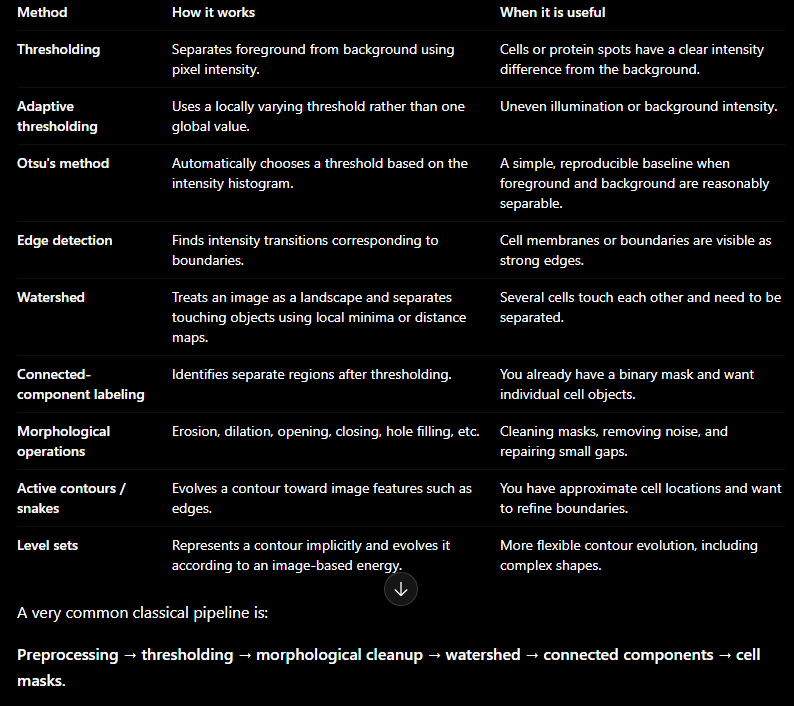

## TODOS

### General
- Bayesian parameter optimization
- - Many methods require the right parameters to work. If i figure some metric for evaluating performance, I can use Bayesian optimization to find the best parameters. This could make simple methods viable. 
### Adaptive thresholding
- Make it truly adaptive. Right now its sampling a lot of uninteresting areas. Perhaps create a burn-in number of circles, and after that only create now circles within a gaussian of interesting points. 
- - or make it human asisted, such that i perhaps click with my mouse on interesting points, and the algorithm adapts based on my input.
- Right now multiple circles append the same points, so theres a lot of redundancy in the final target array. Make it skip points that have already been added.

### Other methods
- Flow. Click on a point in the photo, and it will snap to structure around
- - Or click on an edge, and it will move only along the edge and mark it. 



# Data
## Loading data directly

Todo:
- Need to figure out what the names of the files means. Which z-slice, time point, and other parameters they correspond to.
- I dont think theres any important metadata in the tiff files
- Maybe write image files into a class, with numpy arrays, file name, location, metadata etcs.

In [2]:
data_folder = "C:\\Users\\sjefs\\Desktop\\Uni\\Speciale\\Data\\SharangGarudTopBP1data\\timelapse_tiff_z_proj\\topbp1-timelapse-jf646-10_2_R3D_channel1"
def load_tiff(path):
    """ Loads .tif images in a folder specified by path and returns them as a list of NumPy arrays """
    # First we find all elements of folder at path
    files = [f for f in os.listdir(path) if f.endswith('.tif')]
    images = []
    for f in files:
        im = Image.open(os.path.join(path, f))
        images.append(np.array(im))
    return images

def load_tags(path):
    """ Loads TIFF tags for all .tif images in a folder specified by path and returns them as a list of dictionaries """
    files = [f for f in os.listdir(path) if f.endswith('.tif')]
    tags_list = []
    for f in files:
        im = Image.open(os.path.join(path, f))
        tags = {TAGS[key]: im.tag[key] for key in im.tag.keys()}
        tags_list.append(tags)
    return tags_list

def display_image(image):
    """ Displays a single image using matplotlib """
    plt.imshow(image, cmap='gray')
    plt.colorbar()
    # Show title of file on top
    plt.title("Image")
    plt.show()

images = load_tiff(data_folder)
tags = load_tags(data_folder)

print(tags[0])

{'ImageWidth': (512,), 'ImageLength': (512,), 'BitsPerSample': (16,), 'Compression': (1,), 'PhotometricInterpretation': (1,), 'ResolutionUnit': (1,), 'ImageDescription': ('{"shape": [512, 512]}',), 'StripOffsets': (256,), 'Software': ('tifffile.py',), 'SamplesPerPixel': (1,), 'RowsPerStrip': (512,), 'StripByteCounts': (524288,), 'XResolution': ((1, 1),), 'YResolution': ((1, 1),)}


In [3]:
# Lets animate the images in the folder. I want to be able to scroll between the different frames interactively.
from ipywidgets import interact
import matplotlib.pyplot as plt

def interactive_display(images):
    def view_frame(frame):
        plt.imshow(images[frame], cmap='gray')
        plt.colorbar()
        plt.title(f"Frame {frame}")
        plt.show()
    interact(view_frame, frame=(0, len(images)-1))

interactive_display(images)

interactive(children=(IntSlider(value=12, description='frame', max=25), Output()), _dom_classes=('widget-inter…

## Image class
Lets work with classes. I write this for the files in "timelapse_tiff_z_proj" channel 1. The class will store the image data as a numpy array, along with the file name, location, and any relevant metadata.

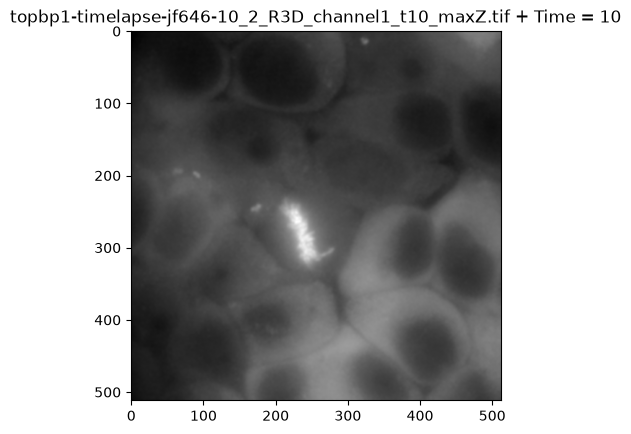

In [3]:
test_path = r"C:\Users\sjefs\Desktop\Uni\Speciale\Data\SharangGarudTopBP1data\timelapse_tiff_z_proj\topbp1-timelapse-jf646-10_2_R3D_channel1\topbp1-timelapse-jf646-10_2_R3D_channel1_t10_maxZ.tif"

test_image = CV_class.Picture(test_path)
test_image.blur()
test_image.display()

# Methods for getting the target particles locations
## Comparing to average / Thresholding
This essentially just masks the highest intensity regions. As some places have high intensity without protein, it may not accurately reflect the presence of the target particles.

#### High Clustering

In [4]:
# Here we try to sort out the high-intensity regions in the image
# We compare high intensity regions to the image average
test_array = test_image.array
mask_array = np.zeros_like(test_array)
Tal = 1.3
mask_array[test_array > test_image.get_average_signal()*Tal] = 1
# Display the mask array next to the original
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(test_array, cmap="gray")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.title("High-Intensity Mask")
plt.axis("off")
plt.imshow(mask_array, cmap="gray")


AttributeError: 'Picture' object has no attribute 'get_average_signal'

#### Low Clustering

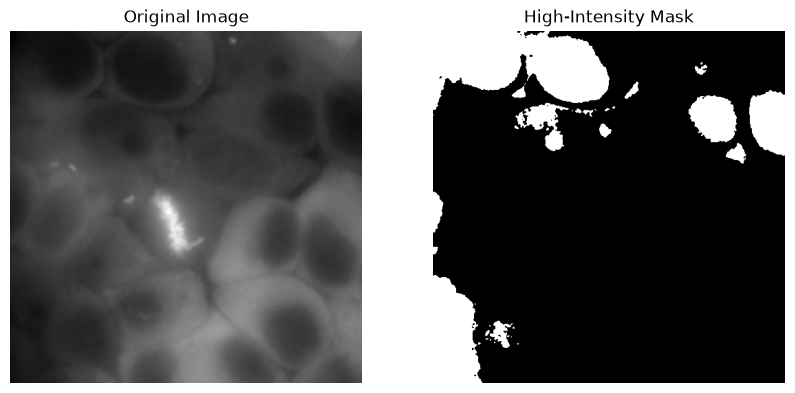

In [50]:
# Here we try to sort out the high-intensity regions in the image
# We compare high intensity regions to the image average
test_array = test_image.array
mask_array = np.zeros_like(test_array)
Tal = 1.3
mask_array[test_array < test_image.get_average_signal()*0.9] = 1
# Display the mask array next to the original
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(test_array, cmap="gray")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.title("High-Intensity Mask")
plt.axis("off")
plt.imshow(mask_array, cmap="gray")


### Adaptive Thresholding Disk method
Basic idea
- Start by creating random circles and figure out a way to find all points within
- Then we can calculate the average intensity within each circle
- Finally, we can set a threshold based on these average intensities to identify regions of interest

Further Extension:
- Perhaps introduce some kind of adaptive stepping, so we sample in interesting areas. Maybe even human assisted, where we click a point, and it marks all the interesting points around it. This could increase efficiency, although its very fast
- Perhaps extend to disks of different scew and orientations, instead of pure circles. 
- Perhaps run the algorithm for N=50 circles, N_repeat = 50 times, and have a vote between the results, random forest style. 

Running Notes:
- Normal thresholding finds a lot of uninteresting points. Adaptive thresholding works a lot better. 
- It runs almost instantly for 100 circles on the 512x512 image. But time depens heavily on circle size. STress testing might be needed

I have written that into functions in an external library

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

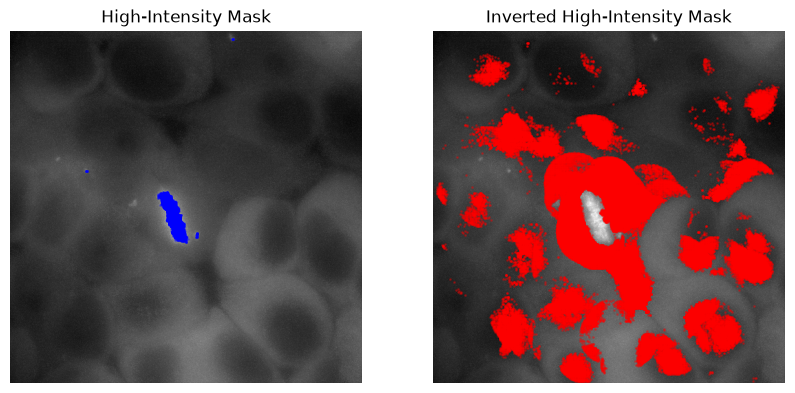

In [ ]:
test_path = r"C:\Users\sjefs\Desktop\Uni\Speciale\Data\SharangGarudTopBP1data\timelapse_tiff_z_proj\topbp1-timelapse-jf646-10_2_R3D_channel1\topbp1-timelapse-jf646-10_2_R3D_channel1_t22_maxZ.tif"
test_image = CV_class.Picture(test_path)
test_array = test_image.array

# Blur it using cv2
#test_array = cv2.GaussianBlur(test_array, (3, 3), 1.4)


plt.figure(figsize=(10, 5))
plt.subplot(1,2,1)
plt.title("High-Intensity Mask")
target_points = CV_func.generate_target_points(test_array, num_circles=500, threshold_factor=1.2, r_min = 10, r_max = 50)
plt.scatter(target_points[:, 0], target_points[:, 1], s=1, c='blue', alpha=0.3)
plt.imshow(test_array, cmap='gray')
plt.axis("off")


test_array_inv = np.max(test_array) - test_array
target_points_inv = CV_func.generate_target_points(test_array_inv, num_circles=500, threshold_factor=1.1, r_min = 10, r_max = 50)
plt.subplot(1,2,2)
plt.title("Inverted High-Intensity Mask")
plt.scatter(target_points_inv[:, 0], target_points_inv[:, 1], s=1, c='red', alpha=0.3)
plt.imshow(test_array, cmap='gray')
plt.axis("off")

#### Stress testing. 
Takes about 20 seconds to run this test. Highest parameters (500 circles with max length 150) takes around 2 seconds. But good results are found from 100 smaller circles of smaller size. Which is almost instant. 

testing N_circles = 20
testing r_min = 10
testing r_min = 40
testing r_min = 70
testing N_circles = 50
testing r_min = 10
testing r_min = 40
testing r_min = 70
testing N_circles = 100
testing r_min = 10
testing r_min = 40
testing r_min = 70
testing N_circles = 200
testing r_min = 10
testing r_min = 40
testing r_min = 70
testing N_circles = 500
testing r_min = 10
testing r_min = 40
testing r_min = 70


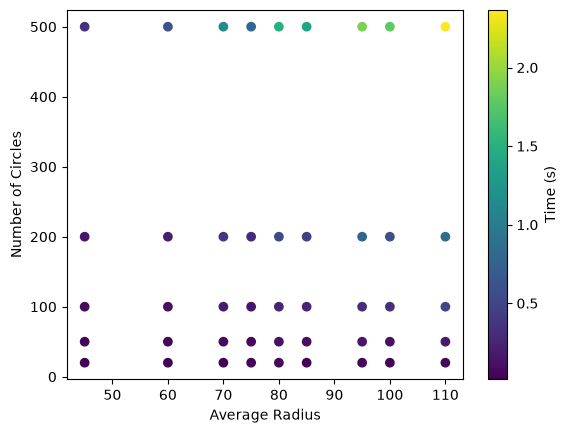

In [ ]:
test_num_circles = np.array([20, 50, 100, 200, 500])
test_r_min = np.array([10, 40, 70])
test_r_max = np.array([80, 130, 150])

import time
timing_results = []
# Now we will try combinations of these hyperparameters, and time them
for num_circles in test_num_circles:
    print("testing N_circles = " + str(num_circles))
    for r_min in test_r_min:
        print("testing r_min = " + str(r_min))
        for r_max in test_r_max:
            start_time = time.time()
            # Call the function to generate circles here, e.g., generate_circles(num_circles, r_min, r_max)
            CV_func.generate_target_points(test_array, num_circles, r_min = r_min, r_max = r_max)
            end_time = time.time()
            timing_results.append((num_circles, (r_max + r_min)/2, end_time - start_time))

# Now we plot it with num_circles on the y axis, and the average radius on the x axis
timing_results = np.array(timing_results)
plt.scatter(timing_results[:,1], timing_results[:,0], c=timing_results[:,2], cmap='viridis')
plt.xlabel('Average Radius')
plt.ylabel('Number of Circles')
plt.colorbar(label='Time (s)')
plt.show()

### Adaptive thresholding openCV
With the right parameters, this works quite well in identifying the target particles

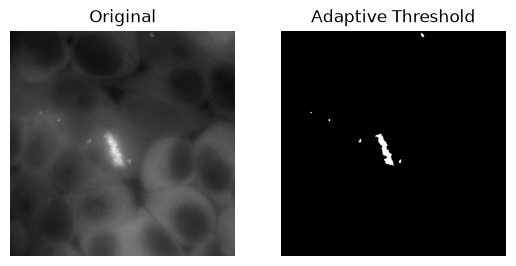

In [ ]:
test_path = r"C:\Users\sjefs\Desktop\Uni\Speciale\Data\SharangGarudTopBP1data\timelapse_tiff_z_proj\topbp1-timelapse-jf646-10_2_R3D_channel1\topbp1-timelapse-jf646-10_2_R3D_channel1_t22_maxZ.tif"
test_image = CV_class.Picture(test_path)
test_array = test_image.array


# adaptiveThreshold requires a single-channel 8-bit image
# Normalize the uint16 image to 0..255 first
gray = test_array.astype(np.float32)
gray = cv2.normalize(gray, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
gray = cv2.GaussianBlur(gray, (5, 5), 1.4)

th1 = cv2.adaptiveThreshold(
    gray,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    blockSize=61,
    C=-20
)
# Display original and th1 side by side
plt.subplot(1, 2, 1)
plt.imshow(test_array, cmap='gray')
plt.title('Original')
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(th1, cmap='gray')
plt.title('Adaptive Threshold')
plt.axis("off")
plt.show()

### Otsu's method
Without the ability to adjust the threshold manually, this is not very viable. 

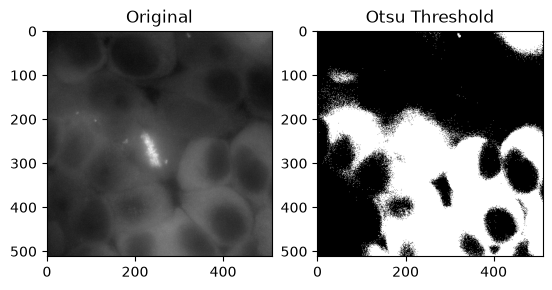

In [ ]:
test_path = r"C:\Users\sjefs\Desktop\Uni\Speciale\Data\SharangGarudTopBP1data\timelapse_tiff_z_proj\topbp1-timelapse-jf646-10_2_R3D_channel1\topbp1-timelapse-jf646-10_2_R3D_channel1_t22_maxZ.tif"
test_image = CV_class.Picture(test_path)
test_array = test_image.array


# adaptiveThreshold requires a single-channel 8-bit image
# Normalize the uint16 image to 0..255 first
gray = test_array.astype(np.float32)
gray = cv2.normalize(gray, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
#gray = cv2.GaussianBlur(gray, (5, 5), 1.4)

ret1, th1 = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Display original and th1 side by side
plt.subplot(1, 2, 1)
plt.imshow(test_array, cmap='gray')
plt.title('Original')
plt.subplot(1, 2, 2)
plt.imshow(th1, cmap='gray')
plt.title('Otsu Threshold')
plt.show()

## Edge detection
### Sobel

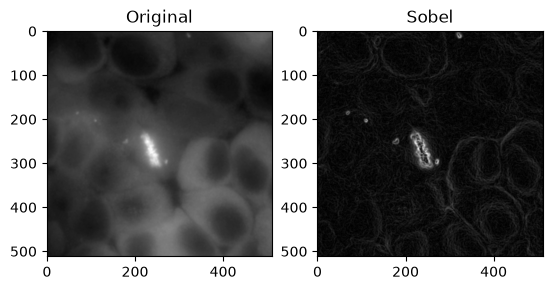

In [ ]:
test_path = r"C:\Users\sjefs\Desktop\Uni\Speciale\Data\SharangGarudTopBP1data\timelapse_tiff_z_proj\topbp1-timelapse-jf646-10_2_R3D_channel1\topbp1-timelapse-jf646-10_2_R3D_channel1_t22_maxZ.tif"
test_image = CV_class.Picture(test_path)
test_array = test_image.array
gray = test_array.astype(np.float32)
gray = cv2.normalize(gray, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
gray = cv2.GaussianBlur(gray, (5, 5), 1.4)

ksize = 3
scale = 1
sobel_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=ksize, scale=scale)
sobel_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=ksize, scale=scale)
sobel = cv2.magnitude(sobel_x, sobel_y)
sobel = cv2.convertScaleAbs(sobel)


# Display original and sobel side by side
plt.subplot(1, 2, 1)
plt.imshow(gray, cmap='gray')
plt.title('Original')
plt.subplot(1, 2, 2)
plt.imshow(sobel, cmap='gray')
plt.title('Sobel')
plt.show()



### Laplacian

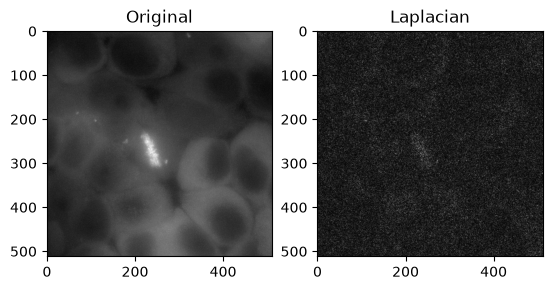

In [ ]:
test_path = r"C:\Users\sjefs\Desktop\Uni\Speciale\Data\SharangGarudTopBP1data\timelapse_tiff_z_proj\topbp1-timelapse-jf646-10_2_R3D_channel1\topbp1-timelapse-jf646-10_2_R3D_channel1_t22_maxZ.tif"
test_image = CV_class.Picture(test_path)
test_array = test_image.array
gray = test_array.astype(np.float32)
gray = cv2.normalize(gray, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

laplacian = cv2.Laplacian(gray, cv2.CV_64F, ksize= 3 )
laplacian = cv2.convertScaleAbs(laplacian)

# Display original and laplacian side by side
plt.subplot(1, 2, 1)
plt.imshow(gray, cmap='gray')
plt.title('Original')
plt.subplot(1, 2, 2)
plt.imshow(laplacian, cmap='gray')
plt.title('Laplacian')
plt.show()

### Watershet

### Currently not working directly. Would require some parameter optimization

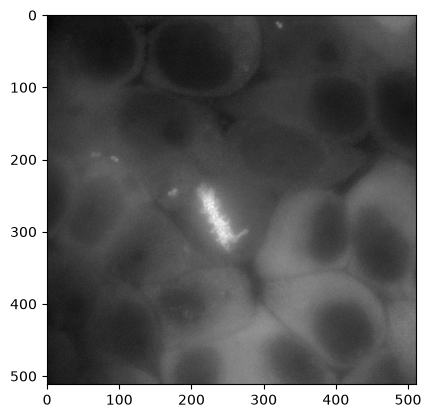

In [13]:
test_path = r"C:\Users\sjefs\Desktop\Uni\Speciale\Data\SharangGarudTopBP1data\timelapse_tiff_z_proj\topbp1-timelapse-jf646-10_2_R3D_channel1\topbp1-timelapse-jf646-10_2_R3D_channel1_t12_maxZ.tif"
test_image = CV_class.Picture(test_path)
test_array = test_image.array
gray = test_array.astype(np.float32)
gray = cv2.normalize(gray, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
plt.imshow(gray, cmap='gray')


### SK-images canny
doesnt seem to work very well
https://stackoverflow.com/questions/55994311/image-segmentation-to-find-cells-in-biological-images

Text(0.5, 1.0, 'Canny Edges')

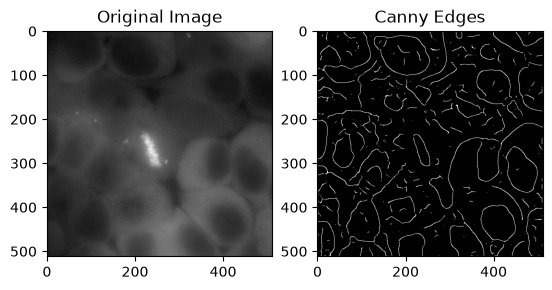

In [ ]:
image = test_image.array


from skimage import feature
sigma_test = np.linspace(0.1, 10, 30)

canny = feature.canny(image, sigma=6, low_threshold=0.1, high_threshold=0.3)

# PLot orignal and edges side by side
plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')

plt.subplot(1, 2, 2)
plt.imshow(canny, cmap='gray')
plt.title('Canny Edges')
plt.show()




### Flow

THe idea is to start from a point, and then check similarity outwards from that point. 
The code currently only compares the intensity of neighboring pixels to determine similarity.
I should add:
- Knowledge about surroundings

Its currently able to do something about edges

Stopped, no more points to try


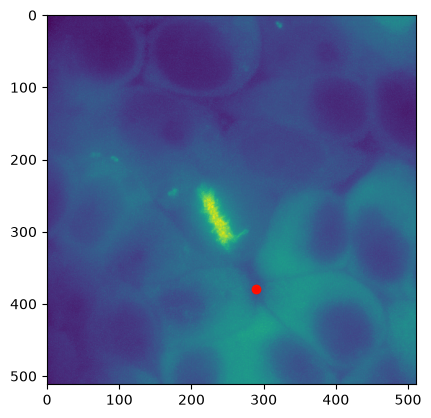

In [15]:
image = test_image.array
plt.imshow(image)
point = 290, 380
similarity_number = 5
meshgrid = np.meshgrid(np.arange(image.shape[1]), np.arange(image.shape[0]))

plt.scatter(*point, color='red')

points_in = [point]
points_out = []
points_to_try = [point]

flag = 0
while True:
    flag += 1
    if len(points_to_try) == 0:
        print("Stopped, no more points to try")
        break

    current_x = points_to_try[-1][0]
    current_y = points_to_try[-1][1]
    points_to_try.remove((current_x, current_y))
    current_intensity = image[current_y, current_x]
    neighbors = [(current_x + dx, current_y + dy) for dx in [-1, 0, 1] for dy in [-1, 0, 1] if (dx, dy) != (0, 0)]
    neighbors = [(x, y) for x, y in neighbors if 0 <= x < image.shape[1] and 0 <= y < image.shape[0]]

    for neighbor_x, neighbor_y in neighbors:
        # Skip if neighbor has already been tried
        if (neighbor_x, neighbor_y) in points_in or (neighbor_x, neighbor_y) in points_out:
            continue
        neighbor_intensity = image[neighbor_y, neighbor_x]

        if abs(int(neighbor_intensity) - int(current_intensity)) < similarity_number:
            points_to_try.append((neighbor_x, neighbor_y))
            points_in.append((neighbor_x, neighbor_y))
            
        else:
            points_out.append((neighbor_x, neighbor_y))

    if flag % 1000 == 0:
        print(" Points left to try: " + str(len(points_to_try)))
    if flag > 6000:
        break

# Lets plot the points in
plt.imshow(image)
points_in_array = np.array(points_in)
plt.scatter(points_in_array[:, 0], points_in_array[:, 1], alpha = 0.05, color='yellow')
plt.show()
